Curator: Louise Marie Maganto

Reviewer: HERE (Your team member's name)

Title: Modeling Cholera Epidemiology Using Stochastic Differential Equations

Pathogen: Cholera 

DOI:  https://doi.org/10.1155/2023/7232395

Figure: 2 (Page 13) 

Outcome: Success 

Notes: B is used as a parameter all conditions were met and the model was reproducable. 

In [ ]:
variable_names = [
    'S',
    'I',
    ]
"""Names of the variables in the SDE model. The order of the variables should be the same as the order of the drift and diffusion terms returned by the drift_term and diffusion_term functions."""

parameter_names = [
    'n',
    'a',
    'K',
    'r',
    'mb', #in the table orginally written as nb-mb but changed to not include the sign
    'e',
    
]
"""Names of the parameters in the SDE model. The order of the parameters should be the same as the order of the values returned by the drift_term and diffusion_term functions."""

initial_values = dict(
    S = 9999,
    I = 1,
    B = 1000

    
)
"""Dictionary of initial values for the variables in the SDE model. The keys should be the variable names in variable_names and the values should be the initial values for those variables."""
 #page 12
parameter_values = dict(
    n = .0001,
    a = 0.5,
    K = 10**6,
    r = 0.2,
    mb = .33,
    e = 10,
    

)
"""Dictionary of values for the parameters in the SDE model. The keys should be the parameter names in parameter_names and the values should be the values for those parameters."""

initial_time = 0.0
"""Initial time to simulate during testing and curation of the SDE model."""

final_time = 120
"""Final time to simulate during testing and curation of the SDE model."""


def drift_term(t, y, p): #page 10
    """The drift term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The drift term(s) of the SDE model in the same order as variable_names
    """
    S, I  = y
    H = S + I
    n, a, K, r, mb, e = p
    return [
        n *(H-S) - (a * B * S) / (K + B),
        ((a * B *S) / (K + B) ) - r * I
    ]
    raise NotImplementedError


def diffusion_term(t, y, p): #page 10 
    """The diffusion term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The diffusion term(s) of the SDE model in the same order as variable_names
    """
    S,I  = y
    H = S + I 
    n, a, K, r, mb, e, B = p
    delta = n* (H + S) + (a * B * S) / (K + B)
    roh = -a * B * S / (K + B)
    omega = (a * B * S / (K + B) ) + r * I
    theta = ( n * (H + S) * (a * B * S) / K + B + r * I + n * (H + S) * r * I) ** 5
    beta = ( n * (H + S) + 2 * a * B * S / K + B + r * I + 2 * theta)

    return [
        (delta + theta / beta) + (roh / beta),
        (roh / beta) + ( omega + theta) / beta

    ]
    raise NotImplementedError

# End Curation

# Begin Testing

*Do not modify anything below this cell.*

Successful implementations can execute the cells below in order without error to produce a figure.

## Do checks

In [3]:
missing_ics = [n for n in variable_names if n not in initial_values]
missing_params = [n for n in parameter_names if n not in parameter_values]

found_errors = False
if len(missing_ics) > 0:
    print(f"Error: Missing initial values for variables: {missing_ics}")
    found_errors = True
if len(missing_params) > 0:
    print(f"Error: Missing values for parameters: {missing_params}")
    found_errors = True
test_drift = drift_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
test_diffusion = diffusion_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
if len(test_drift) != len(variable_names):
    print(f"Error: The drift term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_drift)}.")
    found_errors = True
if len(test_diffusion) != len(variable_names):
    print(f"Error: The diffusion term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_diffusion)}.")
    found_errors = True
if found_errors:
    raise ValueError("Failed to define the SDE model.")

## Do simulation test

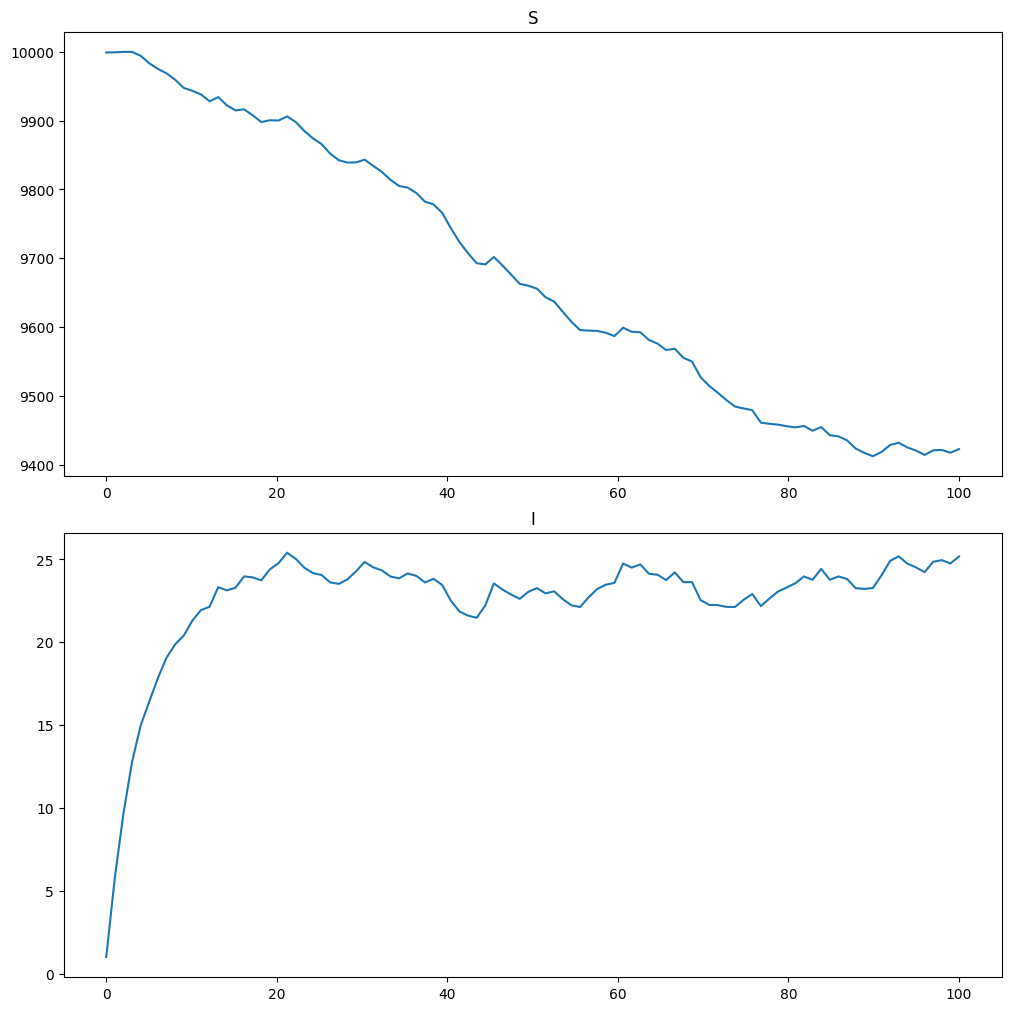

In [4]:
import diffrax
import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import numpy as np

sim_times = np.linspace(initial_time, final_time, 100)
dt = (final_time - initial_time) / 1000
dr_term = diffrax.ODETerm(lambda t, y, p: jnp.array(drift_term(t, y, p)))
br_term = diffrax.VirtualBrownianTree(t0=initial_time, t1=final_time, tol=dt / 10, shape=(), key=jax.random.PRNGKey(0))
di_term = diffrax.ControlTerm(lambda t, y, p: jnp.array(diffusion_term(t, y, p)), br_term)
sde_terms = diffrax.MultiTerm(dr_term, di_term)
solver = diffrax.Euler()
solution = diffrax.diffeqsolve(
    sde_terms,
    solver,
    t0=initial_time,
    t1=final_time,
    dt0=dt,
    y0=jnp.asarray([initial_values[n] for n in variable_names]),
    args=jnp.asarray([parameter_values[n] for n in parameter_names]),
    saveat=diffrax.SaveAt(ts=jnp.asarray(sim_times)),
    max_steps=None,
    throw=True
).ys

fig, axs = plt.subplots(len(variable_names), 1, figsize=(10, 5 * len(variable_names)), layout="constrained")
for i, name in enumerate(variable_names):
    axs[i].plot(sim_times, solution[:, i])
    axs[i].set_title(name)

In [5]:
print('Sucessfully defined the SDE model and generated a test simulation plot.')

Sucessfully defined the SDE model and generated a test simulation plot.
